# Chapter 1: Prompt Chaining

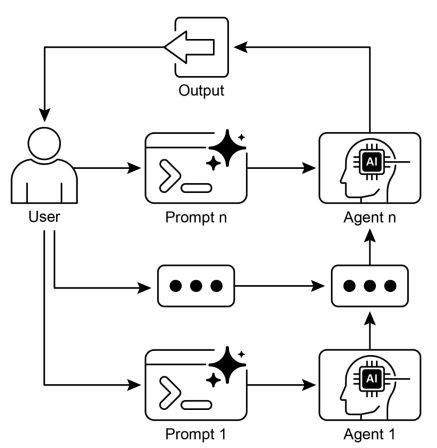

### Core Concept
- **Divide and Conquer**: Break complex tasks into a sequence of smaller, mnagable steps.
- **Dependency Chain**: The output of one prompt becomes the input for the next.
<br>
### Why use it?
- **Avoid Overload**: Large prompts often cause LLMs to hallucinate.
- **Better Control**: Simplier prompts reduce the cognitive load and lead to more accurate result.
- **Easier Debugging**: Find and fix an error in small step than in gaint response.
- **Role Assignment**: Give AI different persona for each step.

### Hands-on Code Example

First, ensure you have the necessary libraries installed:
```
pip install langchain langchain-community langchain-openai langgraph
```

In [1]:
import os, json
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from dotenv import load_dotenv, find_dotenv
from IPython.display import display, Markdown

load_dotenv(find_dotenv(usecwd=True))
API_KEY  = os.environ.get("API_KEY")
BASE_URL = os.environ.get("BASE_URL")

Initialize the Language Model.

In [2]:
llm = ChatOpenAI(
    model="glm-5-turbo",
    api_key=API_KEY,
    base_url=BASE_URL,
    temperature=0
)

Define the prompt.

In [3]:
# Prompt 1: Extract Information
prompt_extract = ChatPromptTemplate.from_template("Extract the technical specificaions from the following text:\n\n{text}")

# Prompt 2: Transform to JSON
prompt_transform = ChatPromptTemplate.from_template("Transform the following specifications into a JSON object with 'cpu', 'memory', and 'storage' as keys:\n\n{specifications}")

Build the Chain using LangChain Expression Language (LCEL). The underlying processing defined will be:
1. `prompt` – takes your input variables and formats them into a prompt then sent to the model.
2. `llm` – sends that formatted prompt to the language model and gets back a response.
3. `StrOutputParser()` – takes the response and extracts plain text as a string.
4. `JsonOutputParser()` – takes the response and converts to JSON.

In [4]:
chain_extract   = prompt_extract | llm | StrOutputParser()
chain_transform   = prompt_transform | llm | JsonOutputParser()
chain = (
    {"specifications": chain_extract}
    | chain_transform
)

Test out the chain.

In [5]:
text = "The new laptop model features a 3.5 GHz octa-core processor, 16GB of RAM, and a 1TB NVMe SSD."
response = chain.invoke({"text": text})
result = json.dumps(response, indent=4)

print("\n--- Final JSON Output ---")
print(result)


--- Final JSON Output ---
{
    "cpu": "3.5 GHz octa-core",
    "memory": "16GB",
    "storage": "1TB NVMe SSD"
}


### Practical Applications & Use Cases

**1 Information Processing Workflows**
<br>
Many tasks involve processing raw information through multiple transformations. For instance, summarizing a document, extracting key entities, and then using those entities to query a database or generate a report. A prompt chain could look like:
- Prompt 1: Extract text content from a given URL or document
- Prompt 2: Summarize the cleaned text.


In [6]:
prompt_extract = ChatPromptTemplate.from_messages([
    ("system", "Extract the content of the academic paper from the given URL."),
    ("user", "Here is the link of academic paper to extract {paper_url}")
])
prompt_summarize = ChatPromptTemplate.from_messages([
    ("system", """
        You are an elite, highly critical Academic Research Assistant. Your purpose is to ingest the full text of an academic paper and conduct a rigorous, phased analysis. 
        You do not just summarize; you critically evaluate methodology, assumptions, and limitations like a peer reviewer.
    
        Analyze the provided paper text using the following four-phase framework. Your output must use the exact headings and bullet points specified below. 
        Be concise, precise, and objective. If information for a specific question is missing from the text, explicitly state: "Not mentioned in text."
        
        ---
        
        ## Output Template
        
        ### 1. The Big Picture
        *   **The Problem:** What specific research gap, question, or problem are the authors trying to solve?
        *   **Significance:** Why does this problem matter? What is the real-world impact or theoretical significance?
        *   **Core Thesis:** In one concise sentence, what is the authors' primary claim or hook?
        
        ### 2. Mechanics & Methodology
        *   **Approach:** What specific methodology, framework, or experimental setup did they use?
        *   **Key Assumptions:** What underlying assumptions did the authors make (e.g., environmental constraints, baseline models, data demographics)?
        *   **Data vs. Claims:** Do the presented results, charts, or metrics logically support their claims? Highlight any gaps between the data and the conclusions drawn.
        
        ### 3. Critical Evaluation & Skepticism
        *   **Limitations:** What are the explicit or implicit limitations of this work (e.g., sample size, computational cost, edge cases)?
        *   **Potential Biases/Conflicts:** Are there visible biases in how the data was framed, or any stated funding conflicts?
        *   **The Unsaid:** What obvious counterarguments, alternative explanations, or variables did the authors fail to address?
        
        ### 4. Future Takeaways
        *   **Contextual Alignment:** How does this work contradict, validate, or expand upon the existing literature in this field?
        *   **Next Steps:** What concrete questions or future research directions does this paper open up?
        *   **Key Assets:** What are the most valuable assets to extract from this paper (e.g., a specific dataset, a novel formula, a robust baseline)?
    """), 
    ("user", "Here is the academic paper to analyze:\n\n{texts}")
])

# EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks
# paper_url = "https://arxiv.org/pdf/1905.11946"

# MyHealthDL: A Prior-Seeded Synthetic Malaysian Clinical Dataset for Multi-Task Deep Learning in Data-Scarce Healthcare Settings
paper_url = "https://openreview.net/pdf?id=HmQQPOJ5jm"

In [7]:
llm = ChatOpenAI(
    model="glm-5.2",
    api_key=API_KEY,
    base_url=BASE_URL,
    reasoning_effort="low",
    temperature=0
)

chain_extract   = prompt_extract | llm | StrOutputParser()
chain_summarize = prompt_summarize | llm | StrOutputParser()
chain = ({"texts": chain_extract} | chain_summarize)
result = chain.invoke({"paper_url": paper_url})

display(Markdown(result))

It appears you have pasted a system or interface message stating an inability to access a PDF link, rather than the actual text of an academic paper. 

As your elite Academic Research Assistant, I am ready to conduct the rigorous, four-phase critical evaluation as soon as I have the source material. 

To proceed, please either:
1. **Copy and paste the text** of the paper (or key sections like the Abstract, Introduction, Methodology, and Conclusion) directly into our chat.
2. **Provide the title and authors** of the paper (if it is a published, well-known paper). 

Once you provide the actual paper text, I will immediately execute the requested four-phase analysis using the exact formatting and critical lens specified.

In [8]:
llm = ChatOpenAI(
    model="glm-5.2",
    api_key=API_KEY,
    base_url=BASE_URL,
    reasoning_effort="medium",
    temperature=0
)

chain_extract   = prompt_extract | llm | StrOutputParser()
chain_summarize = prompt_summarize | llm | StrOutputParser()
chain = ({"texts": chain_extract} | chain_summarize)
result = chain.invoke({"paper_url": paper_url})

display(Markdown(result))

It appears you have provided a message from an AI indicating an inability to access an external link, rather than the actual text of the academic paper. 

To proceed with the rigorous four-phase academic analysis, I need the full text (or at least the key sections: Abstract, Introduction, Methodology, Results, and Discussion) of the paper you want evaluated. 

Please **copy and paste the text** of the paper here, and I will immediately generate the structured, critical review according to your instructions.

In [ ]:
llm = ChatOpenAI(
    model="glm-5.2",
    api_key=API_KEY,
    base_url=BASE_URL,
    reasoning_effort="high",
    temperature=0
)

chain_extract   = prompt_extract | llm | StrOutputParser()
chain_summarize = prompt_summarize | llm | StrOutputParser()
chain = ({"texts": chain_extract} | chain_summarize)
result = chain.invoke({"paper_url": paper_url})

display(Markdown(result))